In [69]:
import numpy as np
import matplotlib.pyplot as plt
import datasets
from privacy_estimates.experiments.aml import JobList
from sklearn.metrics import roc_curve, roc_auc_score
import os
from datetime import datetime
import json

In [70]:
def compute_performance(scores_members, scores_non_members):
    mia_performance = {}
    
    member_vals = [val for val in scores_members]
    non_member_vals = [val for val in scores_non_members]
    mia_performance['auc'] = roc_auc_score([1]*len(member_vals) + [0]*len(non_member_vals), member_vals + non_member_vals)
    fpr, tpr, thresholds = roc_curve([1]*len(member_vals) + [0]*len(non_member_vals), member_vals + non_member_vals)
    for target_fpr in (0.01, 0.05, 0.1):
        mia_performance[f'tpr_at_{target_fpr}'] = np.interp(target_fpr, fpr, tpr)
    print(f"AUC: {mia_performance['auc']}, TPR@0.01: {mia_performance['tpr_at_0.01']}, TPR@0.05: {mia_performance['tpr_at_0.05']}, TPR@0.1: {mia_performance['tpr_at_0.1']}")

    # also add the curves
    mia_performance['fpr'] = fpr
    mia_performance['tpr'] = tpr

    return mia_performance

def compute_performance_from_url(url, job_name = None):
    jobs = JobList.from_urls([url])
    if job_name is None:
        job_name = str(datetime.now())
    
    if not os.path.exists(f'./mia_results/{job_name}'):
        test = jobs[0].get_node('estimate_privacy').download_input('scores', f'./mia_results/{job_name}/scores')
        test = jobs[0].get_node('estimate_privacy').download_input('challenge_bits', f'./mia_results/{job_name}/challenge_bits')
    scores = datasets.load_from_disk(f'./mia_results/{job_name}/scores')
    bits = datasets.load_from_disk(f'./mia_results/{job_name}/challenge_bits')
    
    membership_scores = np.array([k['score'] for k in scores])
    membership_labels = np.array([k['challenge_bit'] for k in bits])
    members = membership_scores[membership_labels == 1]
    non_members = membership_scores[membership_labels == 0]
    return compute_performance(members, non_members)


In [71]:
# read json

with open('ppl_experiment_urls.json') as f:
    all_urls = json.load(f)
all_urls

{'no_synthetic': {'0_5': 'https://ml.azure.com/runs/green_van_7r1zp2ybcw?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
  '5_15': 'https://ml.azure.com/runs/happy_eye_lwk3v3rxqf?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
  '25_35': 'https://ml.azure.com/runs/honest_mangos_x9brk7pbp0?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
  '45_55': 'https://ml.azure.com/runs/bold_shoe_v46y2142ct?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
  '70_80': 'https://ml.azure.com/runs/frank_cloud_pg12snfj36?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PP

In [72]:
# first the non synthetic results

no_synthetic_urls = list(all_urls['no_synthetic'].values())
no_synthetic_ppls = list(all_urls['no_synthetic'].keys())

In [73]:
non_synthetic_results = dict()

for i in range(len(no_synthetic_ppls)):
    print(f"Perplexity: {no_synthetic_ppls[i]}")
    performance = compute_performance_from_url(no_synthetic_urls[i], job_name = f'no_synthetic_{no_synthetic_ppls[i]}')
    non_synthetic_results[no_synthetic_ppls[i]] = performance

Perplexity: 0_5
AUC: 0.7449660133386142, TPR@0.01: 0.19723865877712032, TPR@0.05: 0.39447731755424065, TPR@0.1: 0.4536489151873767
Perplexity: 5_15
AUC: 0.8014050753947773, TPR@0.01: 0.23471400394477318, TPR@0.05: 0.4477317554240631, TPR@0.1: 0.5818540433925049
Perplexity: 25_35
AUC: 0.9092662161783709, TPR@0.01: 0.40631163708086787, TPR@0.05: 0.6844181459566075, TPR@0.1: 0.7554240631163708
Perplexity: 45_55
AUC: 0.9210605278634612, TPR@0.01: 0.47928994082840237, TPR@0.05: 0.7021696252465484, TPR@0.1: 0.7928994082840237
Perplexity: 70_80
AUC: 0.9323387383927251, TPR@0.01: 0.4970414201183432, TPR@0.05: 0.7238658777120316, TPR@0.1: 0.8205128205128205
Perplexity: 95_105
AUC: 0.9268816688070862, TPR@0.01: 0.4970414201183432, TPR@0.05: 0.717948717948718, TPR@0.1: 0.8244575936883629
Perplexity: 120_130
AUC: 0.9052334257514473, TPR@0.01: 0.4240631163708087, TPR@0.05: 0.6429980276134122, TPR@0.1: 0.7692307692307693
Perplexity: 145_155
AUC: 0.925289356713916, TPR@0.01: 0.5877712031558185, TPR@0

In [74]:
# now the synthetic results

synthetic_urls = list(all_urls['synthetic'].values())
synthetic_ppls = list(all_urls['synthetic'].keys())

In [75]:
synthetic_results = dict()

for i in range(len(synthetic_ppls)):
    print(f"Perplexity: {synthetic_ppls[i]}")
    performance = compute_performance_from_url(synthetic_urls[i], job_name = f'synthetic_{synthetic_ppls[i]}')
    synthetic_results[synthetic_ppls[i]] = performance

Perplexity: 0_5
AUC: 0.7416373609227409, TPR@0.01: 0.1952662721893491, TPR@0.05: 0.3037475345167653, TPR@0.1: 0.4280078895463511
Perplexity: 5_15
AUC: 0.7088829410564471, TPR@0.01: 0.10453648915187377, TPR@0.05: 0.22879684418145957, TPR@0.1: 0.3037475345167653
Perplexity: 25_35
AUC: 0.7208412848918387, TPR@0.01: 0.0611439842209073, TPR@0.05: 0.2465483234714004, TPR@0.1: 0.3333333333333333
Perplexity: 45_55
AUC: 0.7645338486343323, TPR@0.01: 0.1282051282051282, TPR@0.05: 0.33530571992110453, TPR@0.1: 0.4477317554240631
Perplexity: 70_80
AUC: 0.7403731131301736, TPR@0.01: 0.10848126232741617, TPR@0.05: 0.3155818540433925, TPR@0.1: 0.39250493096646943
Perplexity: 95_105
AUC: 0.7712151581710015, TPR@0.01: 0.1794871794871795, TPR@0.05: 0.368836291913215, TPR@0.1: 0.46548323471400394
Perplexity: 120_130
AUC: 0.7625614620465612, TPR@0.01: 0.1932938856015779, TPR@0.05: 0.33727810650887574, TPR@0.1: 0.42011834319526625
Perplexity: 145_155
AUC: 0.7531116098755357, TPR@0.01: 0.1755424063116371, T

In [76]:
def get_ppl_val(ppl_str: str):
    return (int(ppl_str.split('_')[0]) + int(ppl_str.split('_')[1])) / 2

no_synthetic_ppl_vals = [get_ppl_val(k) for k in no_synthetic_ppls if k not in ('inf', 'in_canary')]
synthetic_ppl_vals = [get_ppl_val(k) for k in synthetic_ppls if k not in ('inf', 'in_canary')]

In [77]:
import pickle 

with open('ppl_in_canaries_boxplot', 'rb') as f:
    ppl_in_canaries = pickle.load(f)

In [78]:
median_random_token_ppl = 139524.5

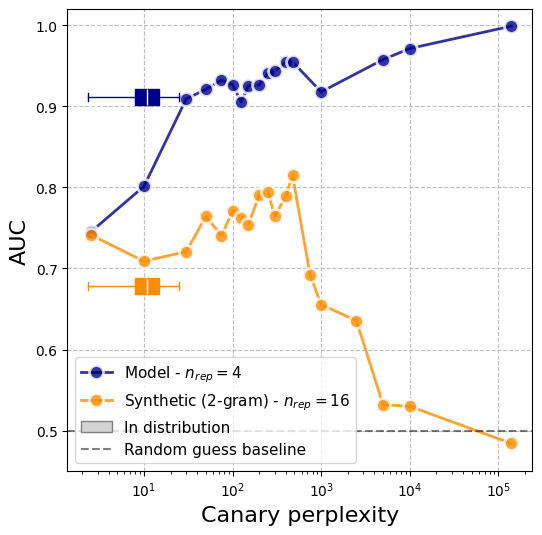

In [84]:
plt.figure(figsize=(6,6))
plt.plot(no_synthetic_ppl_vals + [median_random_token_ppl],
        [non_synthetic_results[p]['auc'] for p in no_synthetic_ppls if p not in ('inf', 'in_canary')] + [non_synthetic_results['inf']['auc']],
        '-o', alpha=0.8, color ='darkblue', markersize=10, linewidth=2, markeredgewidth=2, markeredgecolor='white', label=r'Model - $n_{rep}=4$')

plt.boxplot(
    ppl_in_canaries,
    vert=False,
    positions=[non_synthetic_results['in_canary']['auc']],
    widths=0.02,  # Adjust width to fit your plot
    patch_artist=True,
    boxprops=dict(facecolor='darkblue', color='darkblue'),
    whiskerprops=dict(color='darkblue'),
    capprops=dict(color='darkblue'),
    flierprops=dict(marker='o', color='darkblue', alpha=0.0),
    medianprops=dict(color='white', linewidth=1)  # Change the median line color to red or black
)

plt.plot(synthetic_ppl_vals + [median_random_token_ppl],
        [synthetic_results[p]['auc'] for p in synthetic_ppls if p not in ('inf', 'in_canary')] + [synthetic_results['inf']['auc']],
        '-o', alpha=0.8, color ='darkorange', markersize=10, linewidth=2, markeredgewidth=2, markeredgecolor='white', label=r'Synthetic (2-gram) - $n_{rep}=16$')

plt.boxplot(
    ppl_in_canaries,
    vert=False,
    positions=[synthetic_results['in_canary']['auc']],
    widths=0.02,  # Adjust width to fit your plot
    patch_artist=True,
    boxprops=dict(facecolor='darkorange', color='darkorange'),
    whiskerprops=dict(color='darkorange'),
    capprops=dict(color='darkorange'),
    flierprops=dict(marker='o', color='darkorange', alpha=0.0),
    medianprops=dict(color='white', linewidth=1)  # Change the median line color to red or black
)

# just for the label
plt.boxplot(
    ppl_in_canaries,
    vert=False,
    positions=[2.0],
    widths=0.02,  # Adjust width to fit your plot
    patch_artist=True,
    boxprops=dict(facecolor='lightgrey', color='grey'),
    whiskerprops=dict(color='grey'),
    capprops=dict(color='grey'),
    flierprops=dict(marker='o', color='grey', alpha=0.5),
    medianprops=dict(color='white', linewidth=1), 
    label = 'In distribution'
)

plt.axhline(y=0.5, color='black', linestyle='--', alpha=0.5, label = 'Random guess baseline')

plt.xticks([10**k for k in (0, 1, 2, 3, 4, 5)])
plt.yticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0], labels=['0.5', '0.6', '0.7', '0.8', '0.9', '1.0'])

# Enable the grid
plt.grid(True, which="major", ls="--", alpha=0.8)

plt.legend(loc='lower left', fontsize=11)
plt.xlabel('Canary perplexity', fontsize=16)
plt.ylabel('AUC', fontsize=16)
plt.ylim(0.45, 1.02)
plt.xscale('log')
plt.savefig('figures/ppl_experiment.pdf', dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()